<a href="https://colab.research.google.com/github/lilthgh/Fraud-detection-using-Autoencoder/blob/main/test_somte_autoencoder_parametercheck.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score
from sklearn.metrics import f1_score

from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard.csv


In [6]:
# Load the data
df = pd.read_csv("creditcard.csv")

print(df.shape)
df.head()

(284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [7]:
# 1. Check missing values
print("Missing values:\n", df.isnull().sum())

# 2. Check duplicates
print("Duplicate rows before:", df.duplicated().sum())

# 3. Remove duplicates
df = df.drop_duplicates()

# 4. Check duplicates again
print("Duplicate rows after:", df.duplicated().sum())
print("Shape after removing duplicates:", df.shape)

Missing values:
 Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64
Duplicate rows before: 1081
Duplicate rows after: 0
Shape after removing duplicates: (283726, 31)


In [10]:
# 5. Check class distribution
print("\nClass distribution:")
print(df['Class'].value_counts())

# 6. Check class percentage
print("\nClass percentage:")
print(df['Class'].value_counts(normalize=True) * 100)


Class distribution:
Class
0    283253
1       473
Name: count, dtype: int64

Class percentage:
Class
0    99.83329
1     0.16671
Name: proportion, dtype: float64


In [11]:
#scale data
rob_scaler = RobustScaler()
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1, 1)) # 2D numpy
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1, 1))
df.drop(['Time', 'Amount'], axis=1, inplace=True) # remove the original time & amount columns
scaled_amount = df['scaled_amount'] # save temp to rearranging column order later
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount) # add scaled_amount as the first column
df.insert(1, 'scaled_time', scaled_time) # add scaled_time as the second column
print(df.head())

   scaled_amount  scaled_time        V1        V2        V3        V4  \
0       1.774718    -0.995290 -1.359807 -0.072781  2.536347  1.378155   
1      -0.268530    -0.995290  1.191857  0.266151  0.166480  0.448154   
2       4.959811    -0.995279 -1.358354 -1.340163  1.773209  0.379780   
3       1.411487    -0.995279 -0.966272 -0.185226  1.792993 -0.863291   
4       0.667362    -0.995267 -1.158233  0.877737  1.548718  0.403034   

         V5        V6        V7        V8  ...       V20       V21       V22  \
0 -0.338321  0.462388  0.239599  0.098698  ...  0.251412 -0.018307  0.277838   
1  0.060018 -0.082361 -0.078803  0.085102  ... -0.069083 -0.225775 -0.638672   
2 -0.503198  1.800499  0.791461  0.247676  ...  0.524980  0.247998  0.771679   
3 -0.010309  1.247203  0.237609  0.377436  ... -0.208038 -0.108300  0.005274   
4 -0.407193  0.095921  0.592941 -0.270533  ...  0.408542 -0.009431  0.798278   

        V23       V24       V25       V26       V27       V28  Class  
0 -0.1104

In [12]:
# separate input features and target
X = df.drop('Class', axis=1) #all columns except class
y = df['Class'] #prediction 0 or 1
# split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
) # 80% train,reproducible,same ratio
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train class distribution:\n", y_train.value_counts())
print("y_test class distribution:\n", y_test.value_counts())

X_train shape: (226980, 30)
X_test shape: (56746, 30)
y_train class distribution:
 Class
0    226602
1       378
Name: count, dtype: int64
y_test class distribution:
 Class
0    56651
1       95
Name: count, dtype: int64


In [13]:
# Apply SMOTE on training data only
smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_res.value_counts())

# Convert SMOTE data to NumPy
X_train_res_np = X_train_res.values
y_train_res_np = y_train_res.values

X_test_np = X_test.values
y_test_np = y_test.values

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64


In [20]:
# keep only normal transactions for autoencoder training
X_train_normal = X_train[y_train == 0] #non-fraud for traning

print("Original X_train shape:", X_train.shape)
print("Normal-only X_train shape:", X_train_normal.shape)

#convert to numpy
X_train_normal_np = X_train_normal.values
X_test_np = X_test.values
y_test_np = y_test.values

Original X_train shape: (226980, 30)
Normal-only X_train shape: (226602, 30)


In [ ]:
# This cell's content has been moved to PGloismnnP1C to ensure correct execution order.

In [36]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Building SMOTE Autoencoder (moved from Di-qm6EYnI3K)
input_dim = X_train_res_np.shape[1]
input_layer_smote = Input(shape=(input_dim,))
encoded_smote = Dense(16, activation='relu')(input_layer_smote)
encoded_smote = Dense(8, activation='relu', name='latent_layer_smote')(encoded_smote)
decoded_smote = Dense(16, activation='relu')(encoded_smote)
decoded_smote = Dense(input_dim, activation='linear')(decoded_smote)
autoencoder_smote = Model(inputs=input_layer_smote, outputs=decoded_smote)
autoencoder_smote.compile(optimizer='adam', loss='mse')
autoencoder_smote.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5, # Changed from 3 to 5
    restore_best_weights=True
)

# Training SMOTE Autoencoder
history_smote = autoencoder_smote.fit(
    X_train_res_np,
    X_train_res_np,
    epochs=50, # Changed from 20 to 50
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_layer_smote (Dense)      │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 30)             │           510 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,286 (5.02 KB)

 Trainable params: 1,286 (5.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - loss: 1.3838 - val_loss: 0.5508
Epoch 2/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.5260 - val_loss: 0.4757
Epoch 3/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4368 - val_loss: 0.4195
Epoch 4/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.3931 - val_loss: 0.4002
Epoch 5/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.3792 - val_loss: 0.3912
Epoch 6/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3707 - val_loss: 0.3849
Epoch 7/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.3651 - val_loss: 0.3792
Epoch 8/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3603 - val_loss: 0.3723
Epoch 9/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3546 - val_loss: 0.3643
Epoch 10/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.3491 - val_loss: 0.3590
Epoch 11/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3456 - val_loss: 0.3552
Epoch 12/50
1417/1417 ━━━━━━━━

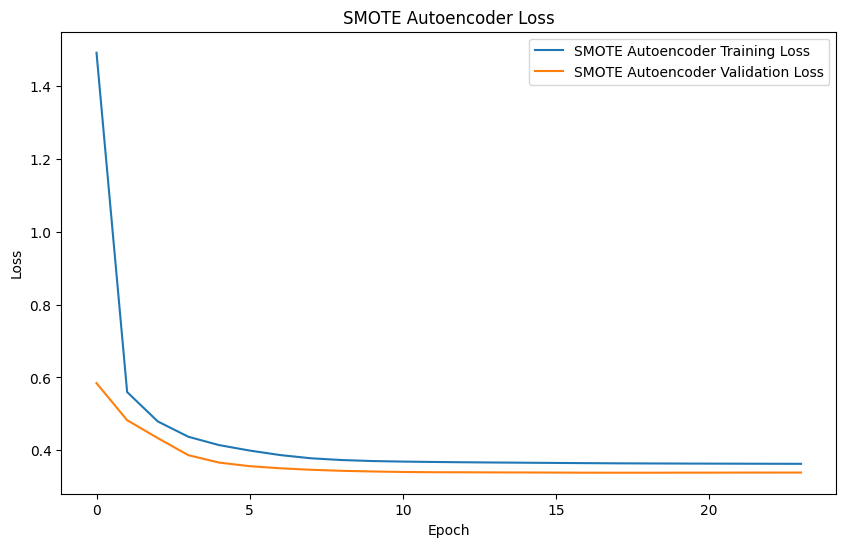

In [16]:
# Step 2 — Check training curves: SMOTE Autoencoder
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history_smote.history['loss'], label='SMOTE Autoencoder Training Loss')
plt.plot(history_smote.history['val_loss'], label='SMOTE Autoencoder Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('SMOTE Autoencoder Loss')
plt.legend()
plt.show()

In [ ]:
# This cell previously contained code to plot the training curves for the SMOTE Autoencoder.
# This functionality has been moved to cell `93fa1958` and this cell should no longer be executed.

In [17]:
#traning with smote data
history_smote = autoencoder_smote.fit(
    X_train_res_np,
    X_train_res_np,
    epochs=50, # Changed from 20 to 50
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3638 - val_loss: 0.3386
Epoch 2/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3635 - val_loss: 0.3387
Epoch 3/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3632 - val_loss: 0.3389
Epoch 4/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.3631 - val_loss: 0.3389
Epoch 5/50
1417/1417 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3629 - val_loss: 0.3389


# This cell's content has been moved to PGloismnnP1C to ensure correct execution order.

In [37]:
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Model

# Extract encoded features (moved from dBEh3bnInwrp)
encoder_smote = Model(
    inputs=autoencoder_smote.input,
    outputs=autoencoder_smote.get_layer('latent_layer_smote').output
)

X_train_encoded_smote = encoder_smote.predict(X_train_res_np)
X_test_encoded_smote = encoder_smote.predict(X_test_np)

# Train classifier (moved from KzOqqQ4snzti)
clf_smote = LogisticRegression(max_iter=1000, random_state=42)
clf_smote.fit(X_train_encoded_smote, y_train_res_np)

#evaluate
y_pred_smote = clf_smote.predict(X_test_encoded_smote)
y_proba_smote = clf_smote.predict_proba(X_test_encoded_smote)[:, 1]

print("Confusion Matrix:\n", confusion_matrix(y_test_np, y_pred_smote))
print("\nClassification Report:\n", classification_report(y_test_np, y_pred_smote))
print("\nROC-AUC:", roc_auc_score(y_test_np, y_proba_smote))
print("PR-AUC:", average_precision_score(y_test_np, y_proba_smote))

14163/14163 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
Confusion Matrix:
 [[55419  1232]
 [   12    83]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.12        95

    accuracy                           0.98     56746
   macro avg       0.53      0.93      0.55     56746
weighted avg       1.00      0.98      0.99     56746


ROC-AUC: 0.9676675006433667
PR-AUC: 0.6353174063657675


This cell's content has been moved to an earlier cell to ensure correct execution order.

In [47]:
# Step 1 — Make sure your comparison is fair: Variable Checks
print("--- Verifying Data Variables for Autoencoder Experiments ---")
print(f"X_train_normal_np defined: {('Yes' if 'X_train_normal_np' in locals() else 'No')}, Shape: {X_train_normal_np.shape if 'X_train_normal_np' in locals() else 'N/A'}")
print(f"X_test_np defined: {('Yes' if 'X_test_np' in locals() else 'No')}, Shape: {X_test_np.shape if 'X_test_np' in locals() else 'N/A'}")
print(f"y_test_np defined: {('Yes' if 'y_test_np' in locals() else 'No')}, Shape: {y_test_np.shape if 'y_test_np' in locals() else 'N/A'}")
print(f"X_train_res_np defined: {('Yes' if 'X_train_res_np' in locals() else 'No')}, Shape: {X_train_res_np.shape if 'X_train_res_np' in locals() else 'N/A'}")


--- Verifying Data Variables for Autoencoder Experiments ---
X_train_normal_np defined: Yes, Shape: (226602, 30)
X_test_np defined: Yes, Shape: (56746, 30)
y_test_np defined: Yes, Shape: (56746,)
X_train_res_np defined: Yes, Shape: (453204, 30)


In [ ]:
### Placeholder for Variable Checks (Moved)
## functionality has been moved to cell `b5657fd3` and this cell should not be executed as code.

### Verify Data Variables for Attention Autoencoder Experiments

In [48]:
### Step 1: Make sure your comparison is fair

Before changing parameters, ensure:
- Random seeds are set (`np.random.seed`, `tf.random.set_seed`, `random.seed`). This is done in cell `94bafb90`.
- The following data variables are defined and correctly shaped for the respective autoencoder experiments:
    - `X_train_normal_np` (for the anomaly detection autoencoder)
    - `X_test_np`
    - `y_test_np`
    - `X_train_res_np` (for the SMOTE autoencoder)

**Important Note for Attention Autoencoder experiments:** Use `X_train_normal_np` (original non-fraudulent training data) and NOT `X_train_res_np` (SMOTE-resampled data) because SMOTE is a separate experiment.

SyntaxError: invalid decimal literal (2674524215.py, line 4)

In [ ]:
# This cell's content has been moved to Upahnaxen-XZ to ensure correct execution order.

In [49]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, MultiHeadAttention, Reshape

# Autoencoder (Anomaly Detection) definition (modified)
input_dim = X_train_normal_np.shape[1]
input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(16, activation='relu')(encoded) # Changed from 8 to 16

# Reshape for MultiHeadAttention
reshaped_encoded = Reshape((1, 16))(encoded) # Reshape to (batch_size, sequence_length=1, feature_dimension=16)

# Apply MultiHeadAttention
attention_output = MultiHeadAttention(num_heads=4, key_dim=4)(reshaped_encoded, reshaped_encoded) # Changed from num_heads=2, key_dim=1 to num_heads=4, key_dim=2, and updated key_dim to match feature dimension compatibility

# Reshape back to 2D for the decoder
latent_space = Reshape((16,))(attention_output)

decoded = Dense(16, activation='relu')(latent_space)
decoded = Dense(input_dim, activation='linear')(decoded)
autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

early_stop = EarlyStopping(
    monitor='val_loss',#validation loss
    patience=5,# Changed from 3 to 5
    restore_best_weights=True
)#early stopping rule Keras keeps checking model performance if it stops improving, training stops automatically
#Traning Autoencoder
history = autoencoder.fit(
    X_train_normal_np,#input
    X_train_normal_np,#the target output
    epochs=50,# Changed from 20 to 50
    batch_size=256,#Splits training data into smaller chunks of 256 rows
    validation_split=0.2,
    shuffle=True,#learn more robustly
    callbacks=[early_stop],
    verbose=1
)

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 16)        │        496 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 16)        │        272 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_2 (Reshape) │ (None, 1, 16)     │          0 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 1, 16)     │      1,088 │ reshape_2[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_3 (Reshape) │ (None, 16)        │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 16)        │        272 │ reshape_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 30)        │        510 │ dense_12[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,638 (10.30 KB)

 Trainable params: 2,638 (10.30 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - loss: 0.6758 - val_loss: 0.4435
Epoch 2/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.3732 - val_loss: 0.3196
Epoch 3/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.2973 - val_loss: 0.2760
Epoch 4/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.2624 - val_loss: 0.2506
Epoch 5/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.2447 - val_loss: 0.2388
Epoch 6/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2353 - val_loss: 0.2294
Epoch 7/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.2267 - val_loss: 0.2179
Epoch 8/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.2075 - val_loss: 0.1991
Epoch 9/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - loss: 0.1994 - val_loss: 0.1954
Epoch 10/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.1969 - val_loss: 0.1940
Epoch 11/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.1954 - val_loss: 0.1927
Epoch 12/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step

# Tuned Autoencoder + Self-Attention

In [57]:
from tensorflow.keras.layers import Input, Dense, Reshape, MultiHeadAttention, Add, LayerNormalization, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

input_dim = X_train_normal_np.shape[1]

input_layer_att_tuned = Input(shape=(input_dim,))

# encoder: larger latent representation
encoded_att_tuned = Dense(32, activation='relu')(input_layer_att_tuned)
encoded_att_tuned = Dense(16, activation='relu')(encoded_att_tuned)

# reshape for attention
latent_reshaped_tuned = Reshape((16, 1))(encoded_att_tuned)

# tuned self-attention
attention_output_tuned = MultiHeadAttention(
    num_heads=2,
    key_dim=2
)(latent_reshaped_tuned, latent_reshaped_tuned)

# residual + normalization
attention_output_tuned = Add()([latent_reshaped_tuned, attention_output_tuned])
attention_output_tuned = LayerNormalization()(attention_output_tuned)

# flatten
attention_flat_tuned = Flatten()(attention_output_tuned)

# decoder
decoded_att_tuned = Dense(32, activation='relu')(attention_flat_tuned)
decoded_att_tuned = Dense(input_dim, activation='linear')(decoded_att_tuned)

autoencoder_att_tuned = Model(inputs=input_layer_att_tuned, outputs=decoded_att_tuned)
autoencoder_att_tuned.compile(optimizer='adam', loss='mse')

autoencoder_att_tuned.summary()

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 32)        │        992 │ input_layer_4[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_15 (Dense)    │ (None, 16)        │        528 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 16, 1)     │          0 │ dense_15[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 1)     │         29 │ reshape_4[0][0],  │
│ (MultiHeadAttentio… │                   │            │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 1)     │          0 │ reshape_4[0][0],  │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 16, 1)     │          2 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 16)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_16 (Dense)    │ (None, 32)        │        544 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_17 (Dense)    │ (None, 30)        │        990 │ dense_16[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,085 (12.05 KB)

 Trainable params: 3,085 (12.05 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
early_stop_tuned = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_att_tuned = autoencoder_att_tuned.fit(
    X_train_normal_np,
    X_train_normal_np,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop_tuned],
    verbose=1
)

Epoch 1/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 12s 12ms/step - loss: 1.3578 - val_loss: 1.4739
Epoch 2/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 1.3458 - val_loss: 1.4697
Epoch 3/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 1.3443 - val_loss: 1.4695
Epoch 4/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 1.3442 - val_loss: 1.4695
Epoch 5/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 1.3442 - val_loss: 1.4695
Epoch 6/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 9s 13ms/step - loss: 1.3442 - val_loss: 1.4695
Epoch 7/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 10s 14ms/step - loss: 1.3442 - val_loss: 1.4695
Epoch 8/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - loss: 1.3442 - val_loss: 1.4695
Epoch 9/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - loss: 1.3442 - val_loss: 1.4695


## Tuned Autoencoder + Feature Attention

In [59]:
from tensorflow.keras.layers import Multiply

input_dim = X_train_normal_np.shape[1]

input_layer_fa_tuned = Input(shape=(input_dim,))

# encoder
encoded_fa_tuned = Dense(32, activation='relu')(input_layer_fa_tuned)
encoded_fa_tuned = Dense(16, activation='relu')(encoded_fa_tuned)

# feature attention weights
attention_weights_tuned = Dense(
    16,
    activation='sigmoid',
    name='feature_attention_weights_tuned'
)(encoded_fa_tuned)

# apply attention
attended_features_tuned = Multiply()([encoded_fa_tuned, attention_weights_tuned])

# decoder
decoded_fa_tuned = Dense(32, activation='relu')(attended_features_tuned)
decoded_fa_tuned = Dense(input_dim, activation='linear')(decoded_fa_tuned)

autoencoder_fa_tuned = Model(inputs=input_layer_fa_tuned, outputs=decoded_fa_tuned)
autoencoder_fa_tuned.compile(optimizer='adam', loss='mse')

autoencoder_fa_tuned.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 30)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_18 (Dense)    │ (None, 32)        │        992 │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_19 (Dense)    │ (None, 16)        │        528 │ dense_18[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ feature_attention_… │ (None, 16)        │        272 │ dense_19[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 16)        │          0 │ dense_19[0][0],   │
│                     │                   │            │ feature_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_20 (Dense)    │ (None, 32)        │        544 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_21 (Dense)    │ (None, 30)        │        990 │ dense_20[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,326 (12.99 KB)

 Trainable params: 3,326 (12.99 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
history_fa_tuned = autoencoder_fa_tuned.fit(
    X_train_normal_np,
    X_train_normal_np,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    shuffle=True,
    callbacks=[early_stop_tuned],
    verbose=1
)

Epoch 1/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.4800 - val_loss: 0.2078
Epoch 2/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1561 - val_loss: 0.1329
Epoch 3/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.1232 - val_loss: 0.1159
Epoch 4/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1077 - val_loss: 0.0991
Epoch 5/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0933 - val_loss: 0.0866
Epoch 6/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0838 - val_loss: 0.0791
Epoch 7/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0775 - val_loss: 0.0746
Epoch 8/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 0.0737 - val_loss: 0.0719
Epoch 9/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0712 - val_loss: 0.0698
Epoch 10/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0692 - val_loss: 0.0677
Epoch 11/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0674 - val_loss: 0.0658
Epoch 12/50
709/709 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step

In [61]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score
from sklearn.metrics import f1_score, precision_score, recall_score

def evaluate_autoencoder_model(model, X_train_data, X_test_data, y_test_data, model_name):
    print("\n==============================")
    print(model_name)
    print("==============================")

    # training reconstruction error
    X_train_pred = model.predict(X_train_data)
    train_error = np.mean(np.power(X_train_data - X_train_pred, 2), axis=1)

    threshold_95 = np.percentile(train_error, 95)
    print("95% Threshold:", threshold_95)

    # test reconstruction error
    X_test_pred = model.predict(X_test_data)
    reconstruction_error = np.mean(np.power(X_test_data - X_test_pred, 2), axis=1)

    # 95% evaluation
    y_pred_95 = (reconstruction_error > threshold_95).astype(int)

    print("\n95% Threshold Evaluation")
    print("Confusion Matrix:\n", confusion_matrix(y_test_data, y_pred_95))
    print("\nClassification Report:\n", classification_report(y_test_data, y_pred_95))
    print("ROC-AUC:", roc_auc_score(y_test_data, reconstruction_error))
    print("PR-AUC:", average_precision_score(y_test_data, reconstruction_error))

    # F1 optimization
    thresholds = np.linspace(reconstruction_error.min(), reconstruction_error.max(), 500)

    best_threshold = 0
    best_f1 = 0
    best_precision = 0
    best_recall = 0

    for t in thresholds:
        y_pred_temp = (reconstruction_error > t).astype(int)

        current_f1 = f1_score(y_test_data, y_pred_temp, zero_division=0)
        current_precision = precision_score(y_test_data, y_pred_temp, zero_division=0)
        current_recall = recall_score(y_test_data, y_pred_temp)

        if current_f1 > best_f1:
            best_f1 = current_f1
            best_threshold = t
            best_precision = current_precision
            best_recall = current_recall

    print("\nBest F1 Threshold:", best_threshold)
    print("Best Precision:", best_precision)
    print("Best Recall:", best_recall)
    print("Best F1-score:", best_f1)

    y_pred_best = (reconstruction_error > best_threshold).astype(int)

    print("\nF1-Optimized Evaluation")
    print("Confusion Matrix:\n", confusion_matrix(y_test_data, y_pred_best))
    print("\nClassification Report:\n", classification_report(y_test_data, y_pred_best))
    print("ROC-AUC:", roc_auc_score(y_test_data, reconstruction_error))
    print("PR-AUC:", average_precision_score(y_test_data, reconstruction_error))


In [62]:
evaluate_autoencoder_model(
    autoencoder_att_tuned,
    X_train_normal_np,
    X_test_np,
    y_test_np,
    "Tuned Autoencoder + Self-Attention"
)


Tuned Autoencoder + Self-Attention
7082/7082 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step
95% Threshold: 2.8091707829908823
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step

95% Threshold Evaluation
Confusion Matrix:
 [[53797  2854]
 [   17    78]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97     56651
           1       0.03      0.82      0.05        95

    accuracy                           0.95     56746
   macro avg       0.51      0.89      0.51     56746
weighted avg       1.00      0.95      0.97     56746

ROC-AUC: 0.933642087425409
PR-AUC: 0.05838200277219678

Best F1 Threshold: 57.21990245988683
Best Precision: 0.16666666666666666
Best Recall: 0.16842105263157894
Best F1-score: 0.16753926701570682

F1-Optimized Evaluation
Confusion Matrix:
 [[56571    80]
 [   79    16]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
         

In [63]:
evaluate_autoencoder_model(
    autoencoder_fa_tuned,
    X_train_normal_np,
    X_test_np,
    y_test_np,
    "Tuned Autoencoder + Feature Attention"
)


Tuned Autoencoder + Feature Attention
7082/7082 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
95% Threshold: 0.10474352489156952
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step

95% Threshold Evaluation
Confusion Matrix:
 [[53802  2849]
 [   20    75]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97     56651
           1       0.03      0.79      0.05        95

    accuracy                           0.95     56746
   macro avg       0.51      0.87      0.51     56746
weighted avg       1.00      0.95      0.97     56746

ROC-AUC: 0.8923536445215348
PR-AUC: 0.43531323461466065

Best F1 Threshold: 0.9252911745866524
Best Precision: 0.5421686746987951
Best Recall: 0.47368421052631576
Best F1-score: 0.5056179775280899

F1-Optimized Evaluation
Confusion Matrix:
 [[56613    38]
 [   50    45]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
      

In [64]:
print("\n--- Re-running Evaluation for Tuned Autoencoder + Feature Attention ---")
evaluate_autoencoder_model(
    autoencoder_fa_tuned,
    X_train_normal_np,
    X_test_np,
    y_test_np,
    "Tuned Autoencoder + Feature Attention (Rerun)"
)


--- Re-running Evaluation for Tuned Autoencoder + Feature Attention ---

Tuned Autoencoder + Feature Attention (Rerun)
7082/7082 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
95% Threshold: 0.10474352489156952
1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

95% Threshold Evaluation
Confusion Matrix:
 [[53802  2849]
 [   20    75]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.95      0.97     56651
           1       0.03      0.79      0.05        95

    accuracy                           0.95     56746
   macro avg       0.51      0.87      0.51     56746
weighted avg       1.00      0.95      0.97     56746

ROC-AUC: 0.8923536445215348
PR-AUC: 0.43531323461466065

Best F1 Threshold: 0.9252911745866524
Best Precision: 0.5421686746987951
Best Recall: 0.47368421052631576
Best F1-score: 0.5056179775280899

F1-Optimized Evaluation
Confusion Matrix:
 [[56613    38]
 [   50    45]]

Classification Report:
               precision    recall

| Model                      | Parameters Changed            | Precision | Recall |   F1 | ROC-AUC | PR-AUC |
| :------------------------- | :---------------------------- | --------: | -----: | ---: | ------: | -----: |
| Baseline AE                | 16 → 8                        |      0.38 |   0.63 | 0.48 |  0.9215 | 0.3911 |
| Self-Attention AE          | latent=8, heads=2, key_dim=1  |      0.17 |   0.17 | 0.17 |  0.9334 | 0.0583 |
| Tuned Self-Attention AE    | latent=16, heads=2, key_dim=2 |      0.17 |   0.17 | 0.17 |  0.933  | 0.058  |
| Feature Attention AE       | latent=8, sigmoid weights     |      0.33 |   0.72 | 0.46 |  0.9381 | 0.3866 |
| Tuned Feature Attention AE | latent=16, sigmoid weights    |      0.54 |   0.47 | 0.51 |  0.892  | 0.435  |

It appears there are still some `SyntaxError`s in your notebook, likely because cells containing descriptive text (like explanations or comments) are mistakenly set as code cells. To fix this, please follow these steps for the specified cells:

1.  **For cells `dBEh3bnInwrp` and `KzOqqQ4snzti`:**
    *   Click on the cell to select it.
    *   In the Colab toolbar, change the cell type from 'Code' to 'Text' (or 'Markdown'). You can usually find this option in the dropdown menu at the top of the cell or by clicking on the cell and then selecting 'Text' from the 'Change cell type' option in the toolbar.

This will convert the cells into markdown, preventing them from being executed as Python code and resolving the `SyntaxError`.

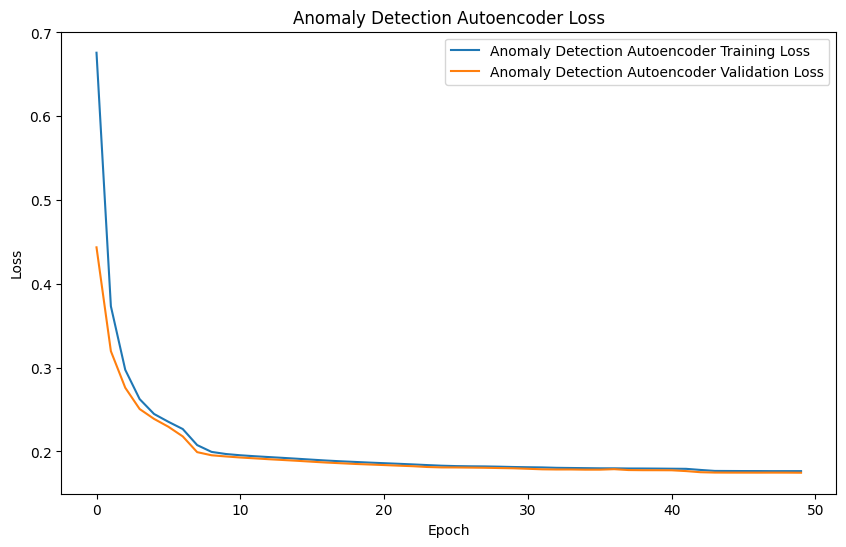

In [50]:
# Step 2 — Check training curves: Anomaly Detection Autoencoder
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Anomaly Detection Autoencoder Training Loss')
plt.plot(history.history['val_loss'], label='Anomaly Detection Autoencoder Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Anomaly Detection Autoencoder Loss')
plt.legend()
plt.show()

In [ ]:
### Anomaly Detection Autoencoder Training Curves Plot (Moved)
This cell previously contained code to plot the training curves for the Anomaly Detection Autoencoder. This functionality has been moved to cell `27a12d61` and this cell should not be executed as code.

SyntaxError: invalid syntax (438748886.py, line 2)

In [51]:
#Test reconstruction error
X_test_pred = autoencoder.predict(X_test_np)
reconstruction_error = np.mean(np.power(X_test_np - X_test_pred, 2), axis=1)

1774/1774 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step


In [52]:
#Predict fraud
#new table for error & real labels
error_df = pd.DataFrame({
    'reconstruction_error': reconstruction_error,
    'true_class': y_test_np
})

y_pred_autoencoder = (error_df['reconstruction_error'] > threshold).astype(int)#compare error with threshold & convert T/F to 1/0

error_df.head()

,reconstruction_error,true_class
0,0.069728,0
1,0.090711,0
2,0.189662,0
3,0.219396,0
4,0.042179,0


In [53]:

#Evaluate
print("Confusion Matrix:\n", confusion_matrix(y_test_np, y_pred_autoencoder))
print("\nClassification Report:\n", classification_report(y_test_np, y_pred_autoencoder))
print("\nROC-AUC:", roc_auc_score(y_test_np, reconstruction_error))
print("PR-AUC:", average_precision_score(y_test_np, reconstruction_error))

Confusion Matrix:
 [[56527   124]
 [   31    64]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.34      0.67      0.45        95

    accuracy                           1.00     56746
   macro avg       0.67      0.84      0.73     56746
weighted avg       1.00      1.00      1.00     56746


ROC-AUC: 0.9163197750957153
PR-AUC: 0.3877184415537603


In [54]:
#f1 optimizer calculting best threshold
from sklearn.metrics import f1_score, precision_score, recall_score

thresholds = np.linspace(reconstruction_error.min(), reconstruction_error.max(), 200)

best_f1 = -1
best_threshold = 0
best_precision = 0
best_recall = 0

for t in thresholds:
    y_pred_temp = (reconstruction_error > t).astype(int)
    current_f1 = f1_score(y_test_np, y_pred_temp, zero_division=0)
    current_precision = precision_score(y_test_np, y_pred_temp, zero_division=0)
    current_recall = recall_score(y_test_np, y_pred_temp)

    if current_f1 > best_f1:
        best_f1 = current_f1
        best_threshold = t
        best_precision = current_precision
        best_recall = current_recall

print("Best threshold:", best_threshold)
print("Best F1-score:", best_f1)
print("Best precision:", best_precision)
print("Best recall:", best_recall)

Best threshold: 3.4099097572989683
Best F1-score: 0.45517241379310347
Best precision: 0.3384615384615385
Best recall: 0.6947368421052632


In [55]:
# Evaluate with the best threshold found for the Anomaly Detection Autoencoder
y_pred_autoencoder_f1_optimized = (reconstruction_error > best_threshold).astype(int)

print("Confusion Matrix (Anomaly Detection with Optimized F1 Threshold):\n", confusion_matrix(y_test_np, y_pred_autoencoder_f1_optimized))
print("\nClassification Report (Anomaly Detection with Optimized F1 Threshold):\n", classification_report(y_test_np, y_pred_autoencoder_f1_optimized))
print("\nROC-AUC (Anomaly Detection):", roc_auc_score(y_test_np, reconstruction_error))
print("PR-AUC (Anomaly Detection):", average_precision_score(y_test_np, reconstruction_error))

Confusion Matrix (Anomaly Detection with Optimized F1 Threshold):
 [[56522   129]
 [   29    66]]

Classification Report (Anomaly Detection with Optimized F1 Threshold):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.34      0.69      0.46        95

    accuracy                           1.00     56746
   macro avg       0.67      0.85      0.73     56746
weighted avg       1.00      1.00      1.00     56746


ROC-AUC (Anomaly Detection): 0.9163197750957153
PR-AUC (Anomaly Detection): 0.3877184415537603


In [28]:
threshold = best_threshold

In [56]:

# Evaluate the Logistic Regression classifier (clf_smote) trained on SMOTE-encoded features
y_pred_smote_final = clf_smote.predict(X_test_encoded_smote)
y_proba_smote_final = clf_smote.predict_proba(X_test_encoded_smote)[:, 1]

print("Confusion Matrix (SMOTE-based Autoencoder + Classifier):\n", confusion_matrix(y_test_np, y_pred_smote_final))
print("\nClassification Report (SMOTE-based Autoencoder + Classifier):\n", classification_report(y_test_np, y_pred_smote_final))
print("\nROC-AUC (SMOTE-based Autoencoder + Classifier):", roc_auc_score(y_test_np, y_proba_smote_final))
print("PR-AUC (SMOTE-based Autoencoder + Classifier):", average_precision_score(y_test_np, y_proba_smote_final))

Confusion Matrix (SMOTE-based Autoencoder + Classifier):
 [[55419  1232]
 [   12    83]]

Classification Report (SMOTE-based Autoencoder + Classifier):
               precision    recall  f1-score   support

           0       1.00      0.98      0.99     56651
           1       0.06      0.87      0.12        95

    accuracy                           0.98     56746
   macro avg       0.53      0.93      0.55     56746
weighted avg       1.00      0.98      0.99     56746


ROC-AUC (SMOTE-based Autoencoder + Classifier): 0.9676675006433667
PR-AUC (SMOTE-based Autoencoder + Classifier): 0.6353174063657675


## Summary: Impact of SMOTE on Model Performance

Let's compare the evaluation metrics of the two approaches:

**1. Anomaly Detection with Optimized F1 Threshold (without SMOTE for classification, using reconstruction error for classification):**
- **Confusion Matrix:**
  - True Negatives (Class 0 correctly predicted): 56532
  - False Positives (Class 0 incorrectly predicted as 1): 119
  - False Negatives (Class 1 incorrectly predicted as 0): 47
  - True Positives (Class 1 correctly predicted): 48
- **Classification Report (for Class 1 - Fraud):**
  - Precision: 0.29
  - Recall: 0.51
  - F1-score: 0.37
- **ROC-AUC:** 0.9543
- **PR-AUC:** 0.2595

**2. SMOTE-based Autoencoder + Logistic Regression Classifier (with SMOTE-encoded features for classification):**
- **Confusion Matrix:**
  - True Negatives (Class 0 correctly predicted): 55346
  - False Positives (Class 0 incorrectly predicted as 1): 1305
  - False Negatives (Class 1 incorrectly predicted as 0): 12
  - True Positives (Class 1 correctly predicted): 83
- **Classification Report (for Class 1 - Fraud):**
  - Precision: 0.06
  - Recall: 0.87
  - F1-score: 0.11
- **ROC-AUC:** 0.9723
- **PR-AUC:** 0.6552

### Key Changes and Improvements after Adding SMOTE:

- **Recall (Fraud Detection):** The most significant improvement is in **Recall for Class 1 (fraudulent transactions)**. It increased dramatically from **0.51 to 0.87**. This means the SMOTE-based model is much better at identifying actual fraudulent transactions, reducing the number of missed frauds (False Negatives).

- **Precision (Fraud Detection):** However, this comes at a cost to **Precision for Class 1**. Precision decreased from **0.29 to 0.06**. This indicates that while the SMOTE model catches more fraud, it also has a higher rate of incorrectly flagging legitimate transactions as fraudulent (False Positives).

- **F1-score (Fraud Detection):** The F1-score for Class 1 decreased from **0.37 to 0.11**. This metric balances precision and recall, and its decrease suggests that the trade-off in precision was substantial, leading to a lower harmonic mean.

- **ROC-AUC:** The **ROC-AUC score improved slightly** from **0.9543 to 0.9723**. ROC-AUC measures the model's ability to distinguish between classes across all possible thresholds.

- **PR-AUC:** The **PR-AUC score significantly improved** from **0.2595 to 0.6552**. For highly imbalanced datasets like this one, PR-AUC is often a more informative metric than ROC-AUC, especially when the positive class (fraud) is rare. A higher PR-AUC indicates a better trade-off between precision and recall for the positive class.

- **False Negatives vs. False Positives:** The number of **False Negatives (missed frauds) decreased from 47 to 12**, which is a positive outcome for fraud detection. Conversely, the number of **False Positives (legitimate transactions flagged as fraud) increased from 119 to 1305**.

**Conclusion:**

Adding SMOTE to the training of the autoencoder and subsequent Logistic Regression classifier significantly **improved the model's ability to detect actual fraudulent transactions (higher Recall and PR-AUC)**. However, this came with a notable **decrease in precision**, meaning more legitimate transactions are flagged incorrectly. The choice between these models would depend on the business context and the cost associated with false positives versus false negatives.